In [ ]:
EXPERIMENT 7

In [ ]:
Scenario 1: Clustering using K-Means

Dataset:https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

In [ ]:
Objective:

To group customers into different clusters based on similarity using K-Means clustering.

In [ ]:
Target Variable:Cluster labels 

Input Features:Annual Income,Spending Score,


K.Nivedha(24BAD082)

EXPERIMENT 7

SCENARIO 1: K-MEANS CLUSTERING



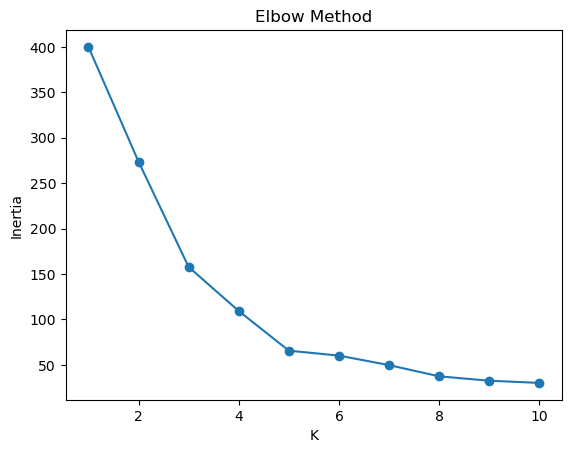

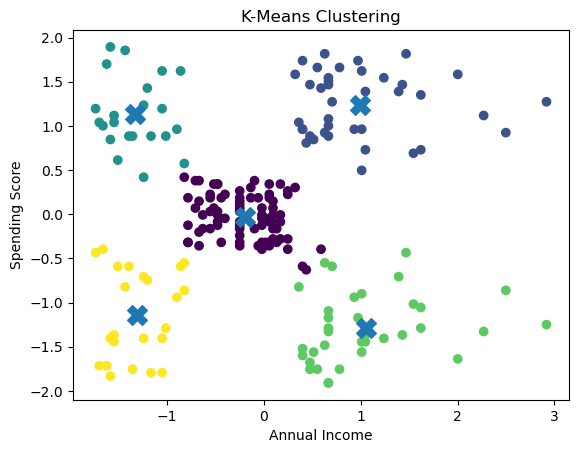

Inertia: 65.56840815571681
Silhouette Score: 0.554657163111109



GMM Cluster Means:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [4]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 7")
print("\nSCENARIO 1: K-MEANS CLUSTERING\n")

import os
os.environ["OMP_NUM_THREADS"] = "1"


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

#LOAD DATASET
df = pd.read_csv(r"C:\Users\nived\Downloads\Mall_Customers.csv")

#SELECT FEATURES
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

#SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#ELBOW METHOD
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

#APPLY K-MEANS
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

#ADD CLUSTER
df['Cluster'] = labels

#VISUALIZATION
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title("K-Means Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

#CENTROIDS
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X')

plt.show()

#EVALUATION
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, labels))
print("\n")

# Cluster Characteristics
print("\nGMM Cluster Means:")
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

In [ ]:
1.Imported required Python libraries.
2.Loaded the dataset.
3.Performed data inspection and preprocessing.
4.Selected relevant features (Income, Spending Score).
5.Applied feature scaling using StandardScaler.
6.Used Elbow Method to determine optimal number of clusters (K).
7.Applied K-Means clustering algorithm.
8.Assigned cluster labels to each data point.
9.Visualized clusters using scatter plot.
10.Evaluated model using:
    Inertia
    Silhouette Score
11.Visualized:
    Elbow curve (K vs inertia)
    Scatter plot of clusters
Cluster centroids

In [ ]:
Output:
-Data points were successfully grouped into clusters based on similarity
-Optimal number of clusters was identified using Elbow Method
-Inertia indicated compactness of clusters
-Silhouette Score showed good separation between clusters
-K-Means formed well-defined and distinct customer segments

In [ ]:
Sceanrio 2:

Dataset:https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

In [ ]:
Objective:

To cluster customers using probabilistic modeling and capture overlapping clusters using GMM.

In [ ]:
Target Variable: Cluster labels and probability of membership

Input Features: Annual Income,Spending Score


K.Nivedha(24BAD082)

EXPERIMENT 7

SCENARIO 2: GMM CLUSTERING



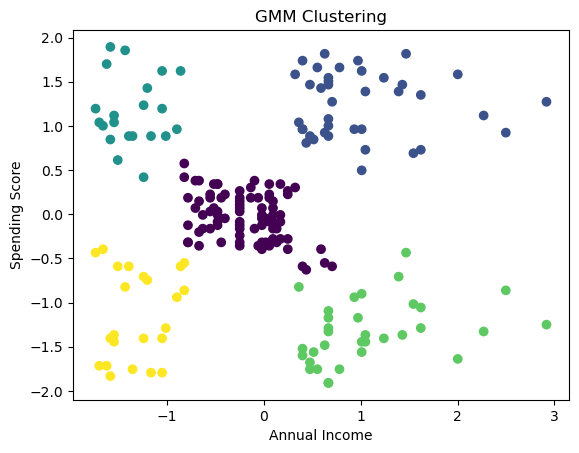

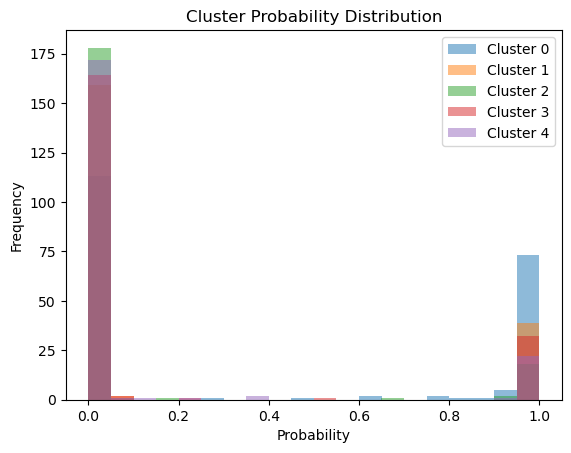

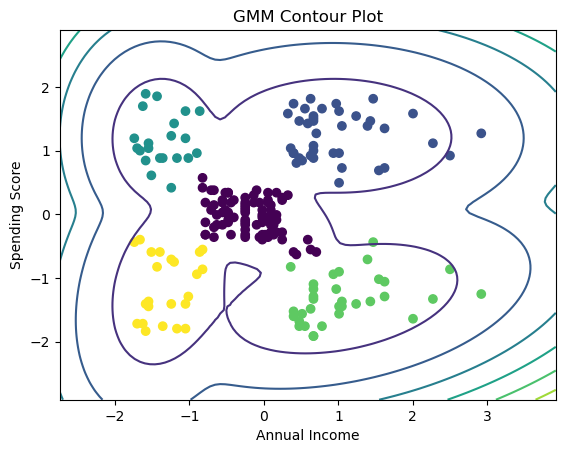

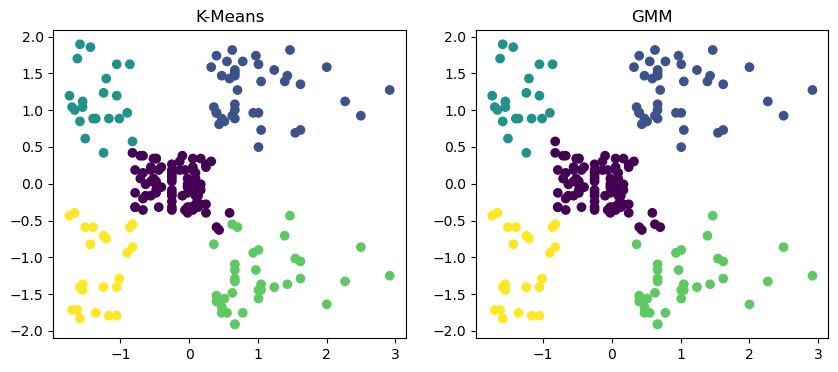

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   GMM_Cluster  
0            4  
1            2  
2            4  
3            2  
4            4  

Cluster Probabilities (First 5 Rows):
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.793900

In [5]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 7")
print("\nSCENARIO 2: GMM CLUSTERING\n")

import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

#LOAD DATASET
df = pd.read_csv(r"C:\Users\nived\Downloads\Mall_Customers.csv")

#SELECT FEATURES
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

#SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#APPLY GMM
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)
probabilities = gmm.predict_proba(X_scaled)

df['GMM_Cluster'] = labels

#GMM SCATTER PLOT
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title("GMM Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

#CLUSTER PROBABILITY DISTRIBUTION
plt.figure()
for i in range(probabilities.shape[1]):
    plt.hist(probabilities[:, i], bins=20, alpha=0.5, label=f'Cluster {i}')

plt.title("Cluster Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

#GMM CONTOUR PLOT
x = np.linspace(X_scaled[:, 0].min()-1, X_scaled[:, 0].max()+1, 100)
y = np.linspace(X_scaled[:, 1].min()-1, X_scaled[:, 1].max()+1, 100)

X_grid, Y_grid = np.meshgrid(x, y)
XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T

Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)

plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title("GMM Contour Plot")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

#COMPARISON (K-MEANS vs GMM)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("K-Means")

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title("GMM")

plt.show()

#EVALUATION
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, labels))

#OUTPUT
print(df.head())

print("\nCluster Probabilities (First 5 Rows):")
print(probabilities[:5])

In [ ]:
1.Loaded dataset.
2.Performed preprocessing and feature scaling.
3.Applied Gaussian Mixture Model (GMM).
4.Selected number of components (clusters).
5.Used Expectation-Maximization (EM) algorithm for training.
6.Predicted cluster labels.
7.Calculated probability of each data point belonging to clusters.
8.Compared results with K-Means clustering.
9.Evaluated model using:
    Log-Likelihood
    AIC
    BIC
    Silhouette Score
10.Visualized:
    Cluster probability distribution
    GMM contour plots
    Comparison plot (K-Means vs GMM)


In [ ]:
Output:
-GMM successfully assigned probabilistic cluster memberships
-Model captured overlapping clusters effectively
-AIC and BIC helped in selecting optimal model
-Log-likelihood indicated goodness of fit
-Silhouette Score showed clustering quality
-GMM provided more flexible clustering compared to K-Means